In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
print("Available Seaborn Datasets:")
print(sns.get_dataset_names())

Available Seaborn Datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
car_crashes = sns.load_dataset('car_crashes')

print("Shape:", car_crashes.shape)
print("\nFirst 5 rows:")
car_crashes.head()

Shape: (51, 8)

First 5 rows:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [5]:
print("Summary Statistics:")
car_crashes.describe()

Summary Statistics:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


In [6]:
print("Missing Values:")
print(car_crashes.isnull().sum())

Missing Values:
total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64


In [7]:
print("Columns:")
print(car_crashes.columns.tolist())

Columns:
['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses', 'abbrev']


/tmp/ipykernel_720/906914122.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='total', y='abbrev', palette='Reds_r', ax=axes[0])
/tmp/ipykernel_720/906914122.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x='total', y='abbrev', palette='Greens', ax=axes[1])


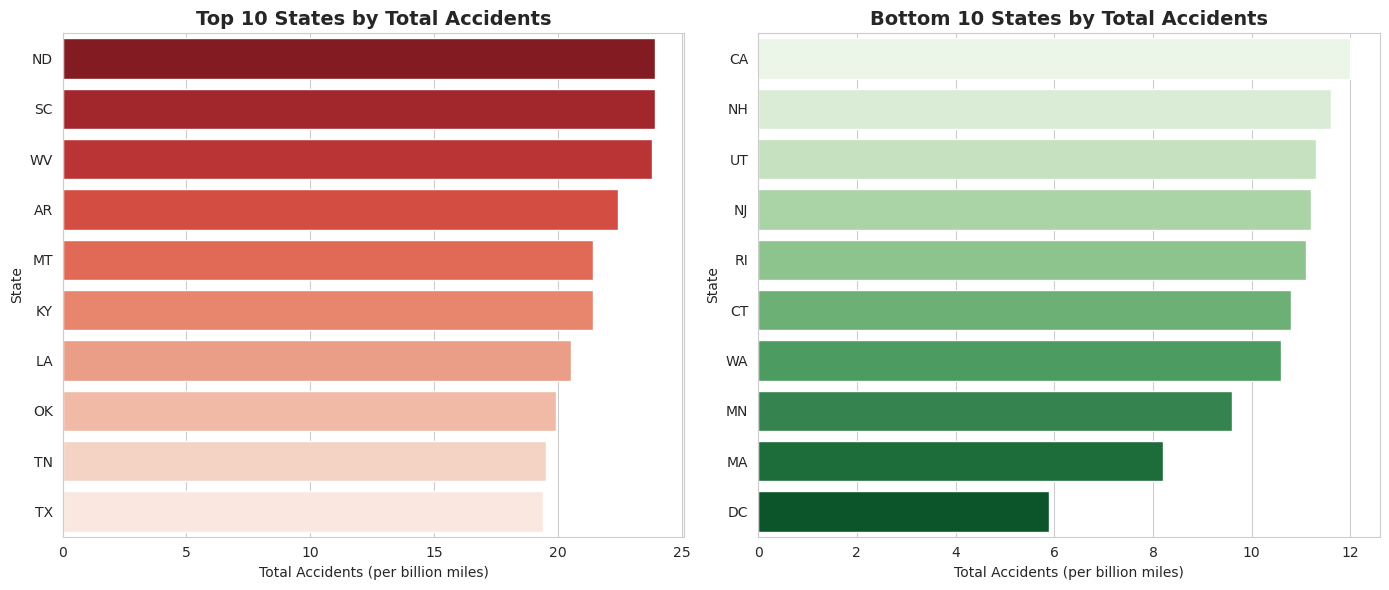

Top 5 States (Highest Accidents):
   abbrev  total
34     ND   23.9
40     SC   23.9
48     WV   23.8
3      AR   22.4
26     MT   21.4

Bottom 5 States (Lowest Accidents):
   abbrev  total
6      CT   10.8
47     WA   10.6
23     MN    9.6
21     MA    8.2
8      DC    5.9


In [8]:
car_crashes_sorted = car_crashes.sort_values('total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10 = car_crashes_sorted.head(10)
sns.barplot(data=top10, x='total', y='abbrev', palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 States by Total Accidents', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Accidents (per billion miles)')
axes[0].set_ylabel('State')

bottom10 = car_crashes_sorted.tail(10)
sns.barplot(data=bottom10, x='total', y='abbrev', palette='Greens', ax=axes[1])
axes[1].set_title('Bottom 10 States by Total Accidents', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Accidents (per billion miles)')
axes[1].set_ylabel('State')

plt.tight_layout()
plt.show()

print("Top 5 States (Highest Accidents):")
print(car_crashes_sorted[['abbrev', 'total']].head())
print("\nBottom 5 States (Lowest Accidents):")
print(car_crashes_sorted[['abbrev', 'total']].tail())

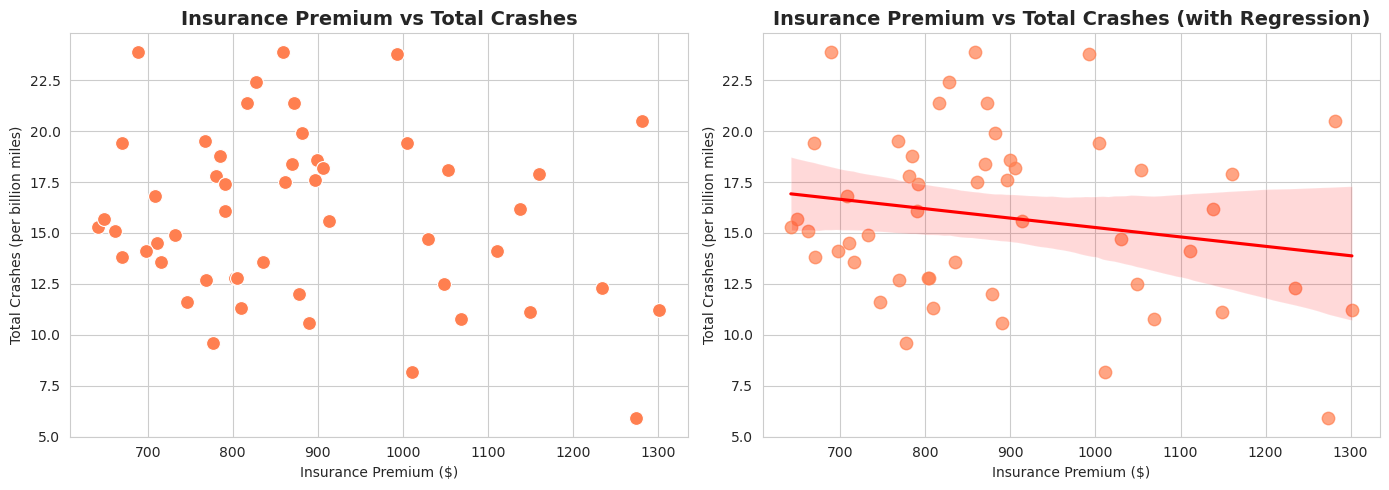

Correlation (Insurance Premium vs Total Crashes): -0.200
Correlation (Insurance Losses vs Total Crashes): -0.036


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=car_crashes, x='ins_premium', y='total',
                color='coral', s=100, ax=axes[0])
axes[0].set_title('Insurance Premium vs Total Crashes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Insurance Premium ($)')
axes[0].set_ylabel('Total Crashes (per billion miles)')

sns.regplot(data=car_crashes, x='ins_premium', y='total',
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'coral'},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Insurance Premium vs Total Crashes (with Regression)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Insurance Premium ($)')
axes[1].set_ylabel('Total Crashes (per billion miles)')

plt.tight_layout()
plt.show()

print(f"Correlation (Insurance Premium vs Total Crashes): "
      f"{car_crashes['ins_premium'].corr(car_crashes['total']):.3f}")
print(f"Correlation (Insurance Losses vs Total Crashes): "
      f"{car_crashes['ins_losses'].corr(car_crashes['total']):.3f}")

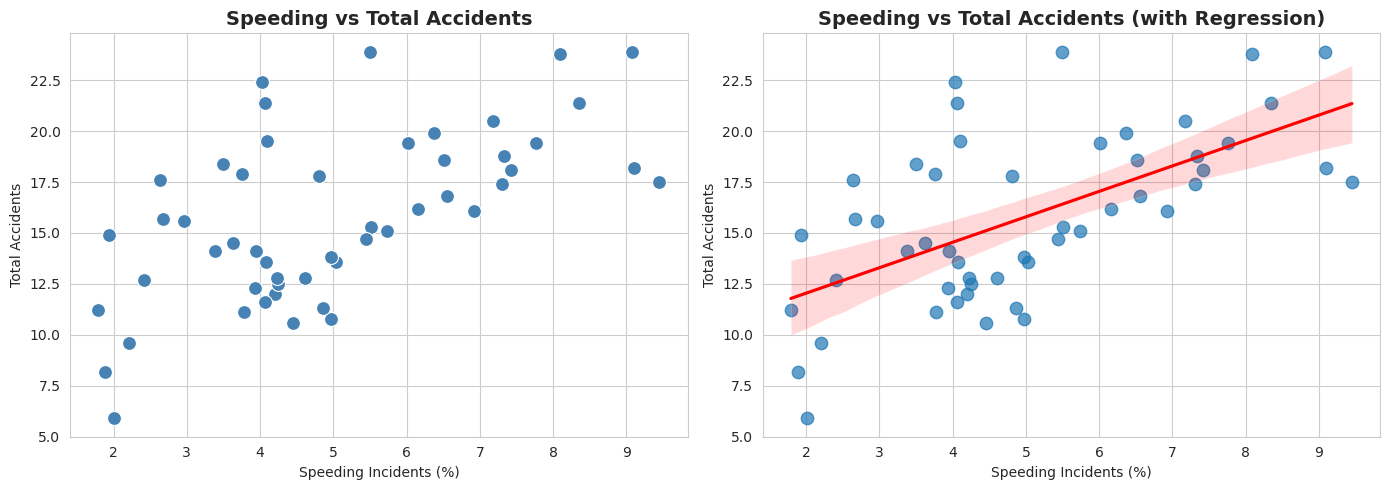

Correlation between Speeding and Total Accidents: 0.612


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=car_crashes, x='speeding', y='total',
                color='steelblue', s=100, ax=axes[0])
axes[0].set_title('Speeding vs Total Accidents', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Speeding Incidents (%)')
axes[0].set_ylabel('Total Accidents')

sns.regplot(data=car_crashes, x='speeding', y='total',
            scatter_kws={'s': 80, 'alpha': 0.7},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Speeding vs Total Accidents (with Regression)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Speeding Incidents (%)')
axes[1].set_ylabel('Total Accidents')

plt.tight_layout()
plt.show()

print(f"Correlation between Speeding and Total Accidents: {car_crashes['speeding'].corr(car_crashes['total']):.3f}")

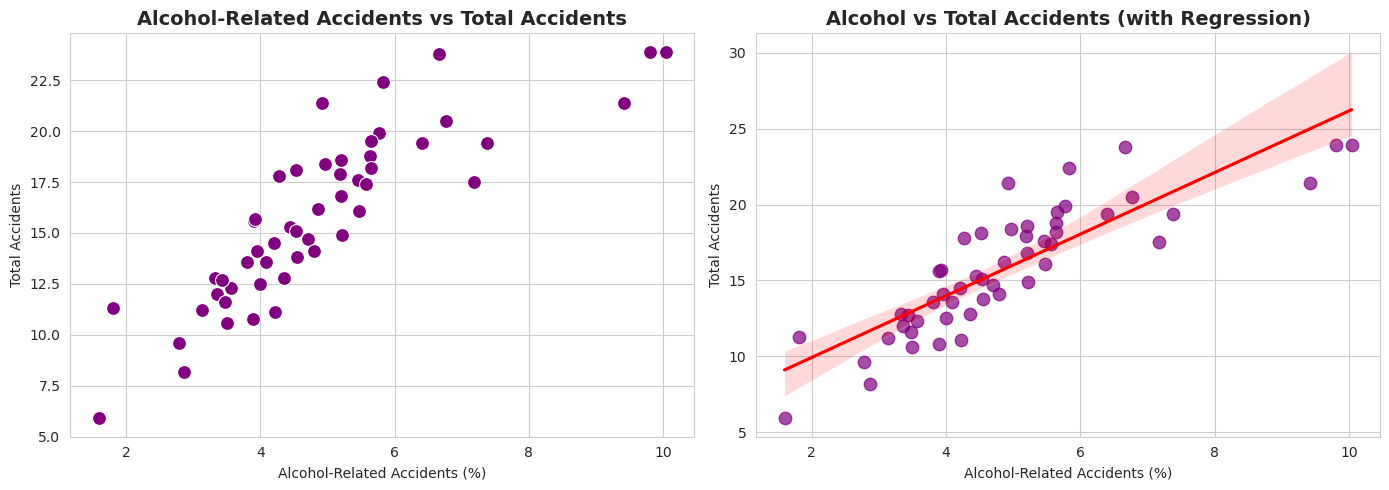

Correlation between Alcohol and Total Accidents: 0.853


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=car_crashes, x='alcohol', y='total',
                color='purple', s=100, ax=axes[0])
axes[0].set_title('Alcohol-Related Accidents vs Total Accidents', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Alcohol-Related Accidents (%)')
axes[0].set_ylabel('Total Accidents')

sns.regplot(data=car_crashes, x='alcohol', y='total',
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'purple'},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Alcohol vs Total Accidents (with Regression)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Alcohol-Related Accidents (%)')
axes[1].set_ylabel('Total Accidents')

plt.tight_layout()
plt.show()

print(f"Correlation between Alcohol and Total Accidents: {car_crashes['alcohol'].corr(car_crashes['total']):.3f}")

Outliers in Total Crashes (Bounds: 4.12 - 27.12):
Empty DataFrame
Columns: [abbrev, total]
Index: []


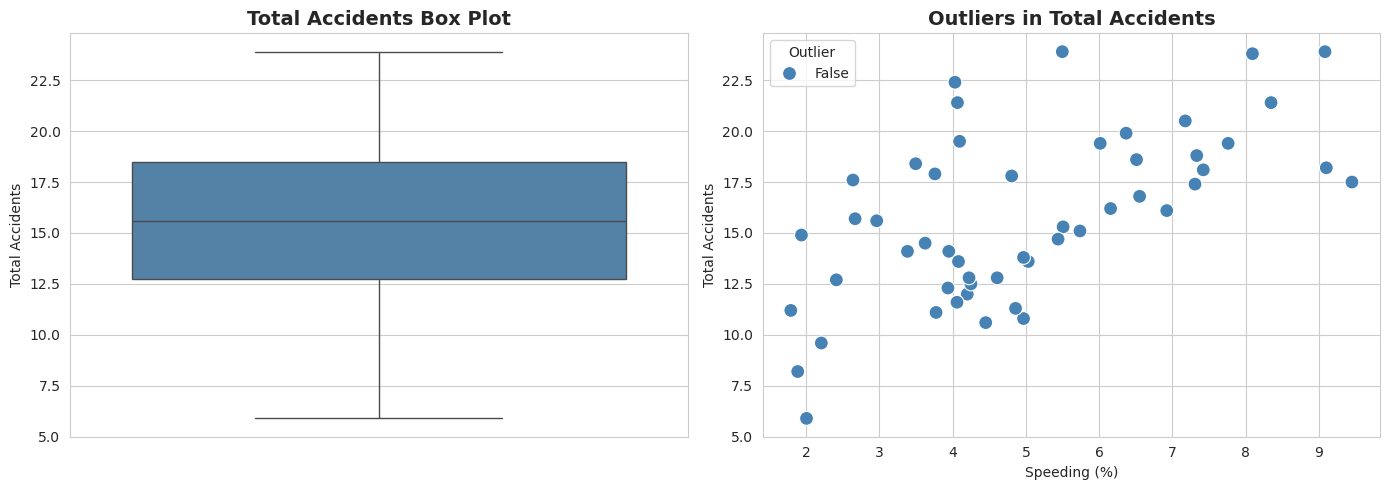

In [17]:
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers, lb, ub = find_outliers(car_crashes, 'total')
print(f"Outliers in Total Crashes (Bounds: {lb:.2f} - {ub:.2f}):")
print(outliers[['abbrev', 'total']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=car_crashes, y='total', color='steelblue', ax=axes[0])
axes[0].set_title('Total Accidents Box Plot', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Accidents')

car_crashes['is_outlier'] = ((car_crashes['total'] < lb) | (car_crashes['total'] > ub))
sns.scatterplot(data=car_crashes, x='speeding', y='total',
                hue='is_outlier', palette={True: 'red', False: 'steelblue'},
                s=100, ax=axes[1])
axes[1].set_title('Outliers in Total Accidents', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Speeding (%)')
axes[1].set_ylabel('Total Accidents')
axes[1].legend(title='Outlier')

plt.tight_layout()
plt.show()

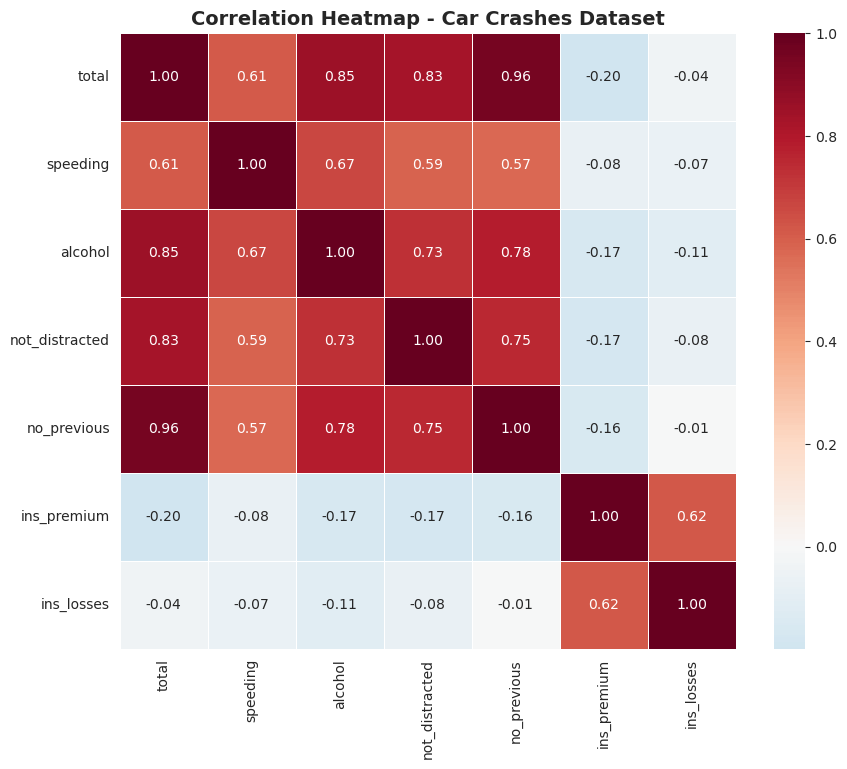

Correlation with Total Crashes:
total             1.000
no_previous       0.956
alcohol           0.853
not_distracted    0.828
speeding          0.612
ins_losses       -0.036
ins_premium      -0.200
Name: total, dtype: float64


In [19]:
numeric_cols = ['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses', 'abbrev']
# Remove abbrev for correlation
numeric_cols = [col for col in car_crashes.columns if car_crashes[col].dtype in ['float64', 'int64'] and col != 'is_outlier']

corr_matrix = car_crashes[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Car Crashes Dataset', fontsize=14, fontweight='bold')
plt.show()

print("Correlation with Total Crashes:")
print(corr_matrix['total'].sort_values(ascending=False).round(3))